<p align="center" style="font-size:24px;"><b>HW 2 - Combined Cycle Power Plant Data</b></p>


## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [460]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [461]:
filepath = "../data/CCPP/Folds5x2_pp.xlsx"
ccpp_df = pd.read_excel(filepath)

ccpp_df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [462]:
print(f"The data set has {ccpp_df.shape[0]} rows and {ccpp_df.shape[1]} columns.")
ccpp_df.head()

The data set has 9568 rows and 5 columns.


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


The data set has 9568 rows and 5 columns. 

The 5 columns with title AT(ambient variables tempreture), V(exhaust vacuum), AP(ambient pressure), RH(relative numidity) and PE(net hourly electrical energy output) represent features of the combined cycle power plant. We will use AT, V, AP, RH as independent variables to predict PE.

Each row with these 5 features represents one observation of features collected from the power plant and the corresponding energy output.

#### ii. pairwise scatterplots of all the varianbles

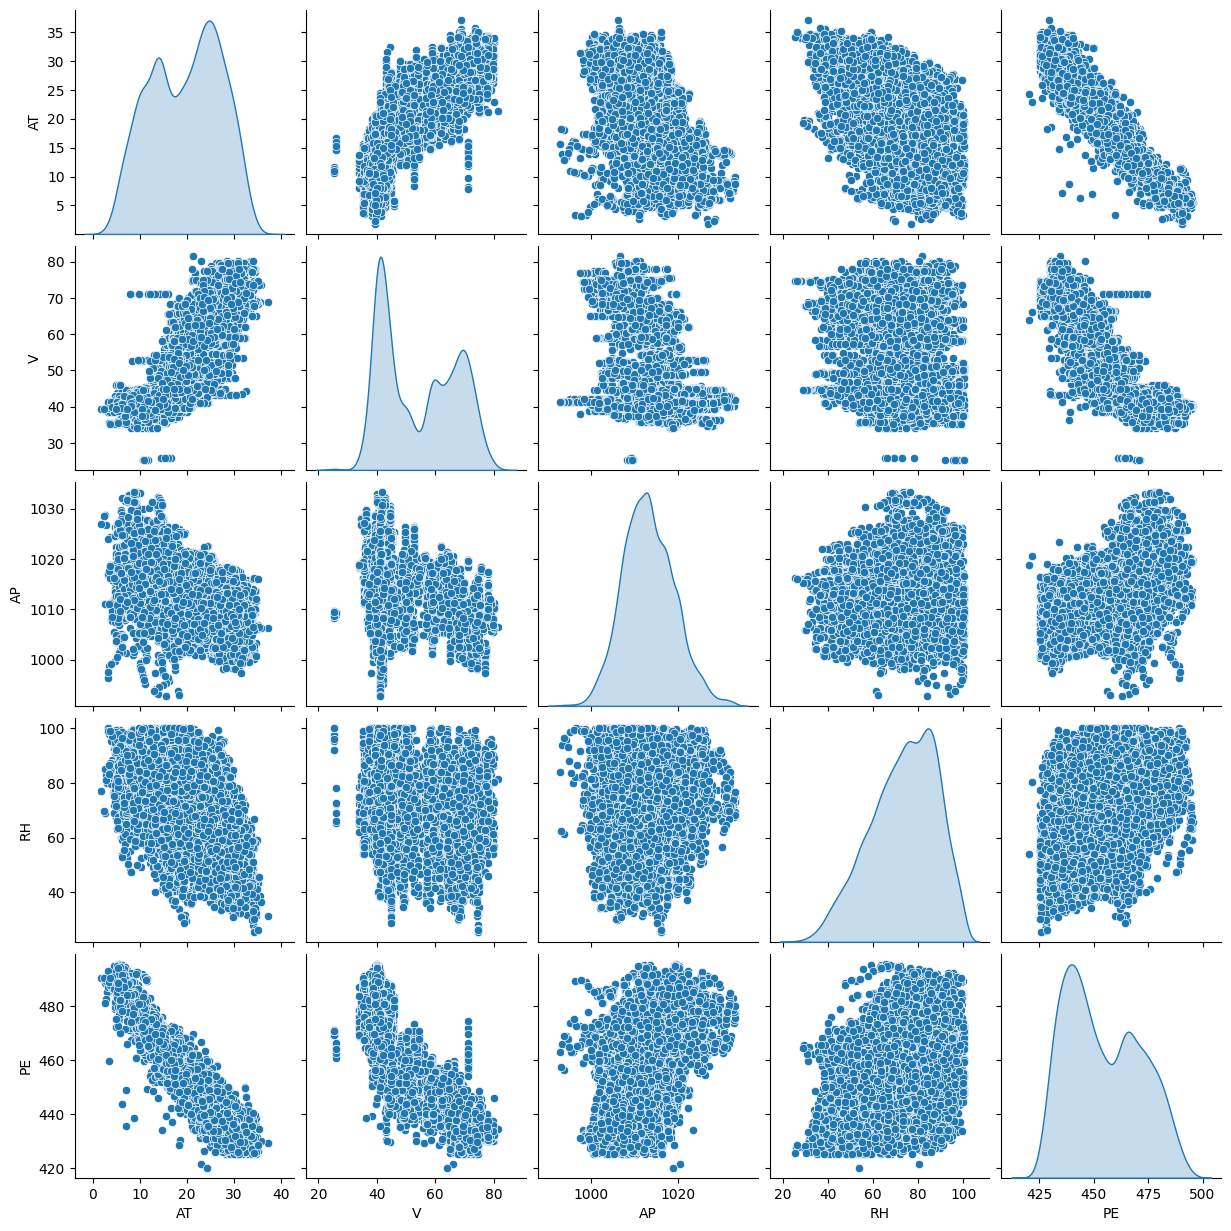

In [463]:
sns.pairplot(ccpp_df, diag_kind="kde")

Observations:

1. AT and PE have negative correlation.
2. V and PE have negative correlation.
3. AT and V have positive correlation.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [464]:
ccpp_summary = pd.DataFrame({
    "Mean": ccpp_df.mean(),
    "Median": ccpp_df.median(),
    "Min": ccpp_df.min(),
    "Max": ccpp_df.max(),
    "Q1": ccpp_df.quantile(0.25),
    "Q3": ccpp_df.quantile(0.75)
})

# Calculate Range and IQR
ccpp_summary["Range"] = ccpp_summary["Max"] - ccpp_summary["Min"]
ccpp_summary["IQR"] = ccpp_summary["Q3"] - ccpp_summary["Q1"]

print(ccpp_summary)

           Mean    Median     Min      Max         Q1       Q3  Range      IQR
AT    19.651231    20.345    1.81    37.11    13.5100    25.72  35.30  12.2100
V     54.305804    52.080   25.36    81.56    41.7400    66.54  56.20  24.8000
AP  1013.259078  1012.940  992.89  1033.30  1009.1000  1017.26  40.41   8.1600
RH    73.308978    74.975   25.56   100.16    63.3275    84.83  74.60  21.5025
PE   454.365009   451.550  420.26   495.76   439.7500   468.43  75.50  28.6800


### (c) Simple Linear Regression

In [465]:
# Define the simple linear regression method
def simple_linear_regression(predictor):
    X = ccpp_df[[predictor]]
    X = sm.add_constant(X)
    y = ccpp_df["PE"]

    # Fit linear regression model
    lr_model = sm.OLS(y, X).fit()
    print(f"\n--- Regression: PE ~ {predictor} ---")
    print(lr_model.summary())

    # Scatterplot + fitted regression line (no outlier highlights yet)
    sns.regplot(x=ccpp_df[predictor], y=ccpp_df["PE"], line_kws={"color": "red"})
    plt.title(f"PE vs {predictor}")
    plt.show()

    # QQ plot of residuals with standardized line
    sm.qqplot(lr_model.resid, line='s')
    plt.title(f"PE vs {predictor} - QQ plot")
    plt.show()

    # Identify outliers using standardized residuals
    influence = lr_model.get_influence()
    standardized_residuals = influence.resid_studentized_internal

    # Mark points with abs(standardized residual) > 2 as outliers
    outliers = abs(standardized_residuals) > 2

    # Scatterplot with outliers highlighted in orange
    plt.scatter(ccpp_df[predictor], ccpp_df["PE"], label="Data")
    plt.scatter(ccpp_df.loc[outliers, predictor],
                ccpp_df.loc[outliers, "PE"],
                color="orange", label="Outliers")
    # Add regression line
    x_vals = np.linspace(ccpp_df[predictor].min(), ccpp_df[predictor].max(), 100)
    y_vals = lr_model.params.iloc[0] + lr_model.params.iloc[1] * x_vals
    plt.plot(x_vals, y_vals, color="red", label="Fitted Line")

    plt.title(f"PE vs {predictor} (Outliers Highlighted)")
    plt.legend()
    plt.show()

    return lr_model


We will perform a simple linear regression for each of the predictors against PE below.

For each regression, we will show the regression table, scatterplot with fitted line, QQ plot and scatterplot with outliers highlighted. In the scatterplot, we will show the fitted line in red. In the QQ plot, to find if there are outliers, we compare the points with a 45-degree reference line. The data is assumed to follow the red reference line to perform a perfect normal distribution. If there are differences, then we will analyze it case by case. For the points whose standardized absolute distance is bigger than 2, we consider them as outliers. This means we are flagging any point that falls into the outermost 5% of the data. We will highlight the outliers by orange in the scatterplot. 

(c.1) Regression: PE ~ AT


--- Regression: PE ~ AT ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:26   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341  

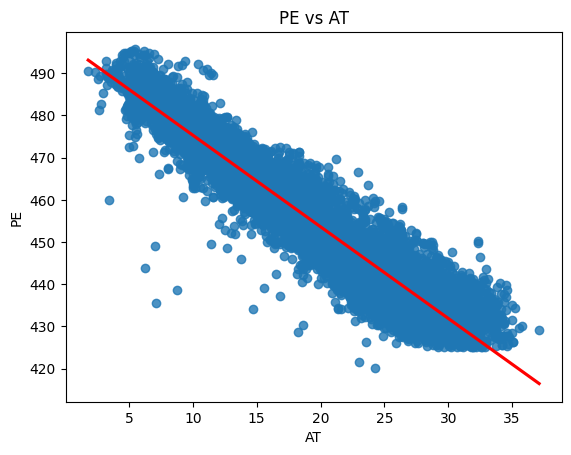

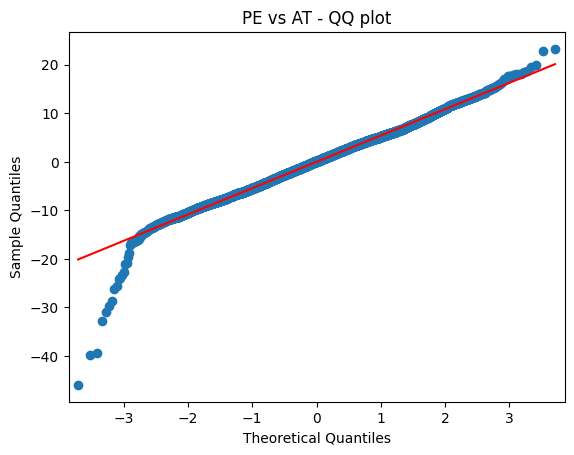

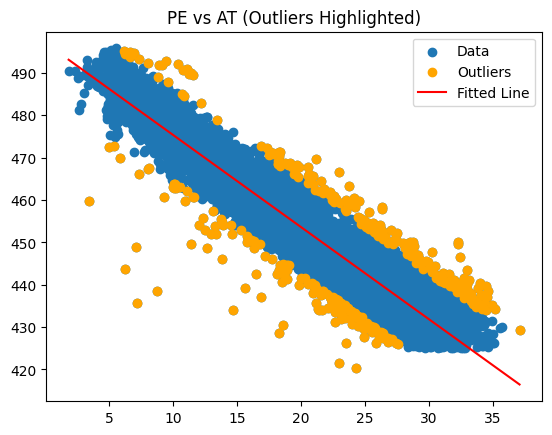

In [466]:
at_slr_model = simple_linear_regression("AT")

From the QQ plot we can see,

1. The main blue points in the middle is aligned with the red reference line. This indicates that most of the data is normally distributed.
2. The left tail of the blue points falls a lot from the red reference line. This indicates that there are some very extreme negative outliers in the data.
3. The right tail of the blue points is slightly above the red reference line. This indicates that there are some positive outliers in the data, but not as extreme as the negative ones.

So overall the QQ plot shows that the residuals of the model(PE ~ AT) mainly follows a normal distribution, but has some negative and positive outliers.

(c.2) Simple Linear Regression: PE ~ V


--- Regression: PE ~ V ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:27   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015   

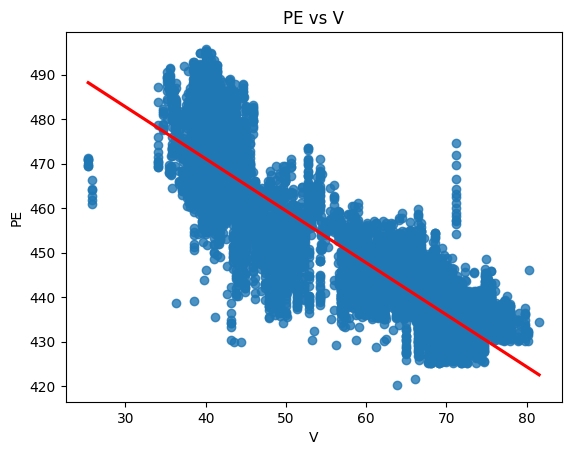

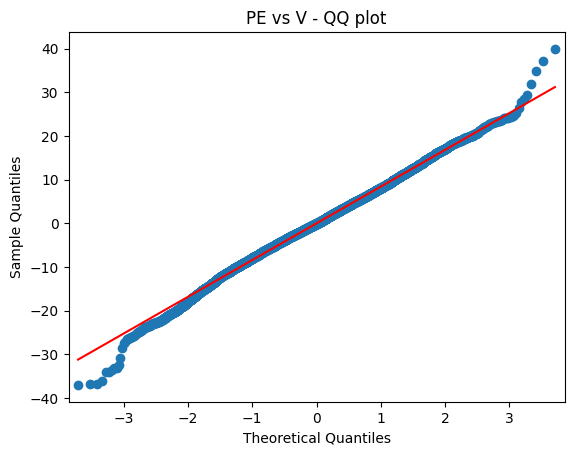

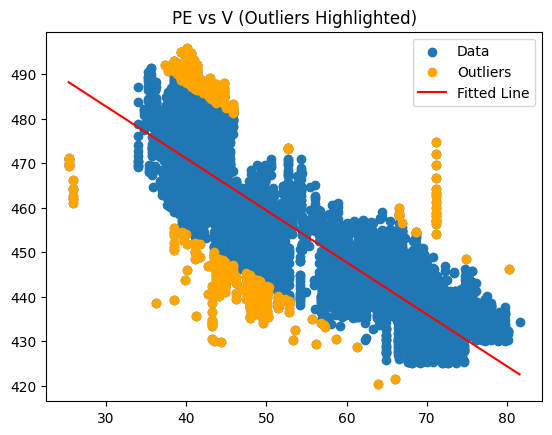

In [467]:
v_slr_model = simple_linear_regression("V")

From the QQ plot we can see,

1. The main blue points in the middle is aligned with the red reference line. This indicates that most of the data is normally distributed.
2. The left tail of the blue points falls a lot from the red reference line. This indicates that there are some very extreme negative outliers in the data.
3. The right tail of the blue points is also far above the red reference line. This indicates that there are some extreme positive outliers in the data.

So overall the QQ plot shows that the residuals of the model(PE ~ V) mainly follows a normal distribution, but has some extreme negative and positive outliers.

(c.3) Simple Linear Regression: PE ~ AP


--- Regression: PE ~ AP ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:27   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610  

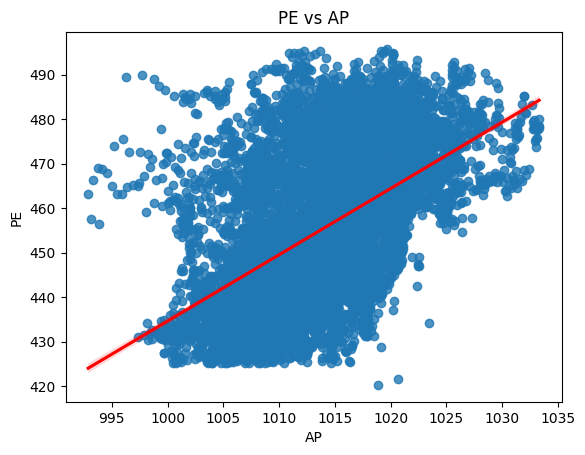

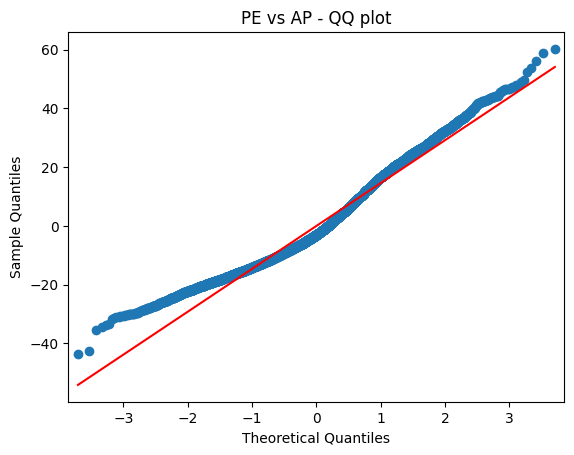

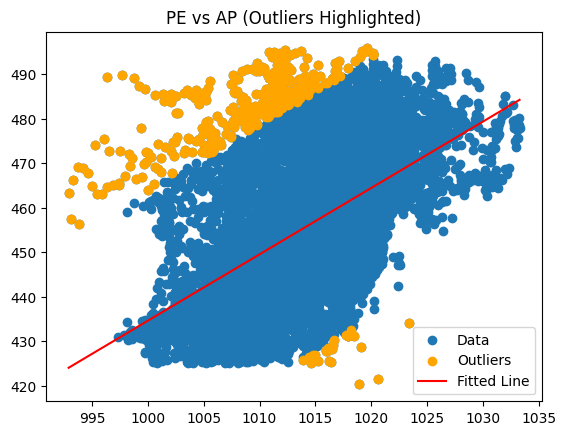

In [468]:
ap_slr_model = simple_linear_regression("AP")

From the QQ plot we can see,

1. The main blue points don't perfectly follow the red reference line. Instead, they perform a slightly s-shape curve. This indicates that the data may not follow a normal distribution.
2. The left tail of the blue points are far above from the red reference line. This indicates that in the lower value region, there are fewer extreme negative errors than what a normal distribution would expect.

So overall the QQ plot shows that the residuals of the model(PE ~ AP) may not perfectly follow a normal distribution, and the model is left light-tailed, which means it has fewer extreme errors that a normal distribution prediction in low-value region.

(c.4) Simple Linear Regression: PE ~ RH


--- Regression: PE ~ RH ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618  

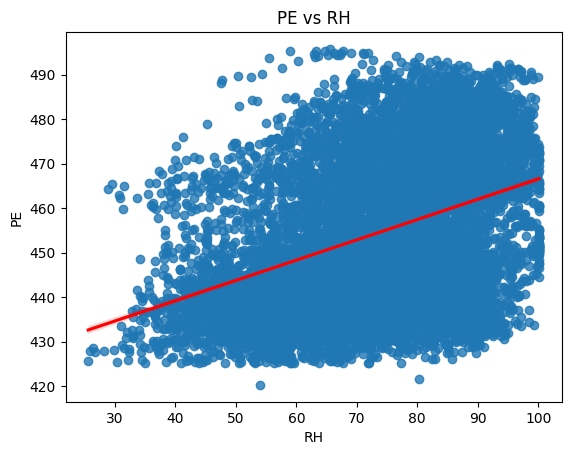

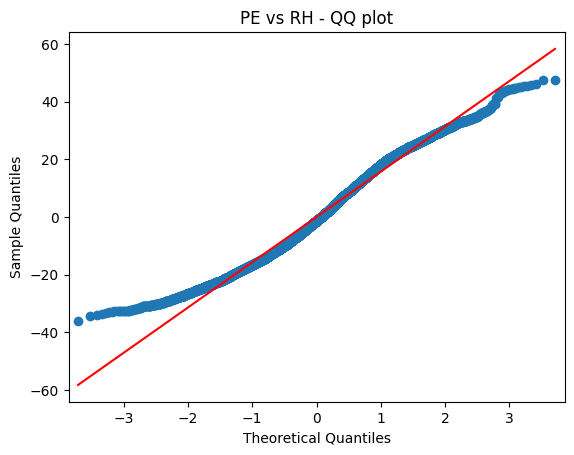

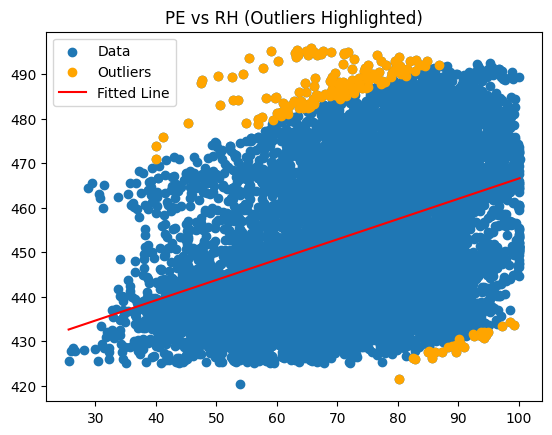

In [469]:
rh_slr_model = simple_linear_regression("RH")

From the QQ plot we can see,

1. The main blue points don't perfectly follow the red reference line. Instead, they perform a slightly s-shape curve. This indicates that the data may not follow a normal distribution.
2. Both left and right end of the curve is light tailed. This indicates that in this model's prediction, there are fewer extreme errors than normal distribution.

So overall the QQ plot shows that the residuals of the model(PE ~ RH) may not perfectly follow a normal distribution, and the model is light-tailed, which means it has fewer extreme errors that a normal distribution prediction.

### (d) Multiple Regression

PE ~ AT + V + AP + RH

In [470]:
X = ccpp_df[["AT", "V", "AP", "RH"]]
X = sm.add_constant(X)
y = ccpp_df["PE"]

# Fit OLS multiple linear regression
mlr_model = sm.OLS(y, X).fit()
print(mlr_model.summary())

# Determine if the predictor is significant
alpha = 0.05
pvalues = mlr_model.pvalues.drop("const")
significant = pvalues[pvalues < alpha]
not_significant = pvalues[pvalues >= alpha]

print("\nSignificant predictors (p < 0.05):")
print(significant.apply(lambda x: f"{x:.4f}"))
print("\nNot significant predictors (p >= {:.2f}):".format(alpha))
print(not_significant)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

From the regression output, we see that all predictors (AT, V, AP, RH) have p-values that are effectively 0. Since these p-values are much less than the significance level of 0.05, we reject the null hypothesis $H_0 : β_j = 0$. We can conclude that all of the 4 predictors are significant. 

### (e) 1c Compare to 1d

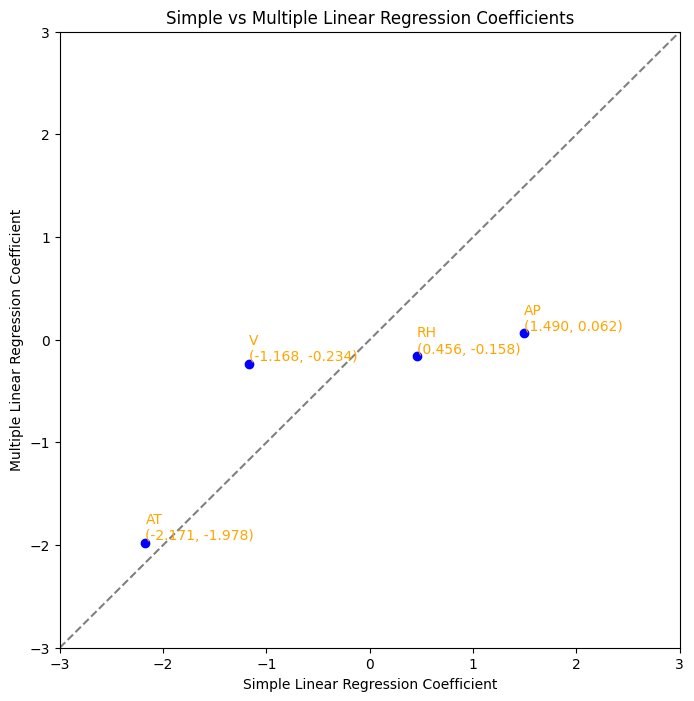

In [471]:
slr_coefficients = [at_slr_model.params["AT"],
                    v_slr_model.params["V"],
                    ap_slr_model.params["AP"],
                    rh_slr_model.params["RH"]]
mlr_coefficients = [mlr_model.params["AT"],
                    mlr_model.params["V"],
                    mlr_model.params["AP"],
                    mlr_model.params["RH"]]

predictors = ["AT", "V", "AP", "RH"]

plt.figure(figsize=(8,8))
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.scatter(slr_coefficients, mlr_coefficients, color="blue")

# Mark the coefficients beside the points
for i, predictor in enumerate(predictors):
    x = slr_coefficients[i]
    y = mlr_coefficients[i]
    plt.text(x, y, f"{predictor}\n({x:.3f}, {y:.3f})", 
             ha="left", va="bottom", color="orange")
    
# Plot the 45 degree reference line
plt.plot([-3, 3], [-3, 3], linestyle="--", color="gray")

plt.xlabel("Simple Linear Regression Coefficient")
plt.ylabel("Multiple Linear Regression Coefficient")
plt.title("Simple vs Multiple Linear Regression Coefficients")
plt.show()


Findings:

1. AT(-2.171, -1.978)

    The coefficients are close in two models. And the point is close to the y=x line. This means the coefficient of AT is stable, and is generally not affected by other variables.

2. V(-1.168, -0.234)

    The sign of the coefficients remains the same, but the magnitude has decreased in the multiple linear regression model. This indicates that V and PE are negatively correloated. However, there are some other variables which are correlated to V. So in simple linear regression model, it over estimated the influence of V.

3. AP(1.490, 0.062)

    Similar to V, sign of the coefficients of AP remains the same, but the absolute value of the slope dropped a lot. This indicates that the influence of AP has been mainly covered by other variables. The simple linear regression model over estimated the influence of AP.

4. RH(0.456, -0.158)

    The sign of the coefficients changed in the two models. This indicates that it may have negative correlation with some other variables. In the multiple regression, when we split the influence of different variables, it reflects the real correlation between RH and PE.


### (f) Nonlinear Association

In [472]:
# Define the method to create polynomial regression model
def poly_regression(predictor):
    X = ccpp_df[[predictor]]
    X2 = X**2
    X3 = X**3

    X.columns = [predictor]
    X2.columns = [f"{predictor}^2"]
    X3.columns = [f"{predictor}^3"]
    
    # Concatenate terms
    X_poly = pd.concat([X, X2, X3], axis=1)
    X_poly = sm.add_constant(X_poly)
    
    y = ccpp_df["PE"]
    
    model = sm.OLS(y, X_poly).fit()
    print(f"\n--- Polynomial Regression: PE ~ {predictor} + {predictor}^2 + {predictor}^3 ---")
    print(model.summary())
    
    return model

(f.1) PE ~ AT + AT^2 + AT^3

In [473]:
at_pr_model = poly_regression("AT")


--- Polynomial Regression: PE ~ AT + AT^2 + AT^3 ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

From the table we can tell the p-value for coefficients of AT, AT^2 and AT^3 are effectively 0, which means we can reject the null hypothesis. The three terms are significant. This implies that there is a strong non-linear(polynomial) correlation between AT, AT^2, AT^3 and PE.

(f.2) PE ~ V + V^2 + V^3

In [474]:
v_pr_model = poly_regression("V")


--- Polynomial Regression: PE ~ V + V^2 + V^3 ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

From the table we can tell the p-value for coefficient of V is effectively 0 and coefficient of V^3 is less than 0.05. This means terms V and V^3 are significant. However, the p-value of the coefficient of V^2 is 0.768 which is larger than 0.05. This indicates the term V^2 is not significant. So we can reject null hypothesis H<sub>0</sub> for V and V^3, but fail to reject the null hypothesis for V^2.

From the information we can still conclude that there is a strong non-linear correlation between terms of V and PE.

(f.3) PE ~ AP + AP^2 + AP^3

In [475]:
ap_pr_model = poly_regression("AP")


--- Polynomial Regression: PE ~ AP + AP^2 + AP^3 ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

From the table we can tell the p-value for coefficients of AP, AP^2 and AP^3 are effectively 0, which means we can reject the null hypothesis. The three terms are significant. This implies that there is a strong non-linear(polynomial) correlation between AP, AP^2 and AP^3 and PE.

(f.4) PE ~ RH + RH^2 + RH^3

In [476]:
rh_pr_model = poly_regression("RH")


--- Polynomial Regression: PE ~ RH + RH^2 + RH^3 ---
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

From the table we can tell the p-value for coefficients of RH, RH^2 and RH^3 are effectively 0, which means we can reject the null hypothesis. The three terms are significant. This implies that there is a strong non-linear(polynomial) correlation between RH, RH^2 and RH^3 and PE.

### (g) Interactions of Predictors

Create the interaction linear regression model with all the predictors and all pairwise interaction terms:

PE ~ AT + V + AP + RH + AT\*V + AT\*AP + AT\*RH + V\*AP + V\*RH + AP\*RH

In [477]:
interaction_model = smf.ols("PE ~ AT + V + AP + RH + AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH", data=ccpp_df).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

From the table above, we can filter out the terms that are statistically significant, whose p-value is less than 0.05.

The terms are: V, AP, RH, AT\*V, AT\*RH, V\*AP, AP\*RH.

This indicates that the interaction terms have significant associations with the response PE.

### (h) Improvement

In [478]:
# Split into 70% training and 30% testing data
train_ccpp_df = ccpp_df.sample(frac=0.7, random_state=36)   # Use a fixed integer in random_state to ensure reproducibility of the random split
test_ccpp_df = ccpp_df.drop(train_ccpp_df.index)

(h.1) Linear Regression Model

PE ~ AT + V + AP + RH

In [479]:
sample_mlr_model = smf.ols("PE ~ AT + V + AP + RH", data=train_ccpp_df).fit()
print(sample_mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 2.171e+04
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -19673.
No. Observations:                6698   AIC:                         3.936e+04
Df Residuals:                    6693   BIC:                         3.939e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.7004     11.769     38.464      0.0

In [480]:
mlr_train_pred = sample_mlr_model.predict(train_ccpp_df)
mlr_train_mse = mean_squared_error(train_ccpp_df["PE"], mlr_train_pred)

mlr_test_pred = sample_mlr_model.predict(test_ccpp_df)
mlr_test_mse = mean_squared_error(test_ccpp_df["PE"], mlr_test_pred)

print("Multiple Linear Regression:")
print(f"    Train MSE: {mlr_train_mse:.4f}")
print(f"    Test MSE:  {mlr_test_mse:.4f}")

Multiple Linear Regression:
    Train MSE: 20.8309
    Test MSE:  20.6321


(h.2) Regression model involving all possible interaction terms and quadratic nonlinearities

PE ~ AT + V + AP + RH + AT\*V + AT\*AP + AT\*RH + V\*AP + V\*RH + AP\*RH + AT<sup>2</sup> + V<sup>2</sup> + AP<sup>2</sup> + RH<sup>2</sup>

In [481]:
sample_inter_poly_model = smf.ols(formula="PE ~ AT + V + AP + RH + " \
                                        "AT*V + AT*AP + AT*RH + V*AP + V*RH + AP*RH + " \
                                        "I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)", 
                                        data=train_ccpp_df).fit()
print(sample_inter_poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7199.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -19202.
No. Observations:                6698   AIC:                         3.843e+04
Df Residuals:                    6683   BIC:                         3.854e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7103.7077   1481.888     -4.794      0.0

From the table we can check the p-value of each term. For those terms whose p-value is less than 0.05, we consider these terms as significant. And for those terms whose p-value is bigger than 0.05, these are not statistically significant, so we will remove them from the model and rebuild.

Significant terms:

V, AP, RH, AT\*V, AT\*RH, V\*AP, AP\*RH, AT<sup>2</sup>, AP<sup>2</sup>, RH<sup>2</sup>

Non-significant terms:

AT, AT\*AP, V\*RH, V<sup>2</sup>

To build the new updated model, we will use the significant terms, and note that AT is not significant but AT<sup>2</sup> is significant, we will still keep AT as a term to keep the hierarchy of the model.

So the new model will be,

PE ~ AT + V + AP + RH + AT\*V + AT\*RH + V\*AP + AP\*RH + AT<sup>2</sup> + AP<sup>2</sup> + RH<sup>2</sup>

In [482]:
sample_inter_poly_model = smf.ols(formula="PE ~ AT + V + AP + RH + " \
                                        "AT*V + AT*RH + V*AP + AP*RH + " \
                                        "I(AT**2) + I(AP**2) + I(RH**2)", 
                                        data=train_ccpp_df).fit()
print(sample_inter_poly_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9162.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        20:12:28   Log-Likelihood:                -19204.
No. Observations:                6698   AIC:                         3.843e+04
Df Residuals:                    6686   BIC:                         3.851e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7678.0530   1275.170     -6.021      0.0

In [483]:
inter_poly_train_pred = sample_inter_poly_model.predict(train_ccpp_df)
inter_poly_train_mse = mean_squared_error(train_ccpp_df["PE"], inter_poly_train_pred)

inter_poly_test_pred = sample_inter_poly_model.predict(test_ccpp_df)
inter_poly_test_mse = mean_squared_error(test_ccpp_df["PE"], inter_poly_test_pred)

print("Interaction + Polynomial Model:")
print(f"    Train MSE: {inter_poly_train_mse:.4f}")
print(f"    Test MSE:  {inter_poly_test_mse:.4f}")

Interaction + Polynomial Model:
    Train MSE: 18.1083
    Test MSE:  18.1503


### (i) KNN

We will use standard scaler to generate the normalized data.
$$
z = \frac{x - \mu}{\sigma}
$$
Because we don't have too many extreme outliers for each variable, and different variables have different scales, we choose StandardScaler so that all variables contribute equally to distance computations in KNN regression.

In [484]:
# Generate training data
X_train = train_ccpp_df.drop(columns=["PE"]).values
y_train = train_ccpp_df["PE"].values

# Generate test data
X_test = test_ccpp_df.drop(columns=["PE"]).values
y_test = test_ccpp_df["PE"].values

# Normalize X for training and test data
scaler = StandardScaler().fit(X_train)
X_train_norm = scaler.transform(X_train)
X_test_norm = scaler.transform(X_test)

train_mse_raw, test_mse_raw = [], []
train_mse_norm, test_mse_norm = [], []

k_values = range(1, 101)
for k in k_values:
    # Raw feature
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)
    y_train_pred_raw = knn_raw.predict(X_train)
    y_test_pred_raw = knn_raw.predict(X_test)
    train_mse_raw.append(mean_squared_error(y_train, y_train_pred_raw))
    test_mse_raw.append(mean_squared_error(y_test, y_test_pred_raw))

    # Normalized feature
    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(X_train_norm, y_train)
    y_train_pred_norm = knn_norm.predict(X_train_norm)
    y_test_pred_norm = knn_norm.predict(X_test_norm)
    train_mse_norm.append(mean_squared_error(y_train, y_train_pred_norm))
    test_mse_norm.append(mean_squared_error(y_test, y_test_pred_norm))

# Find the least train and test error and their corresponding k value
least_train_mse_raw = min(train_mse_raw)
optimal_train_k_raw = k_values[np.argmin(train_mse_raw)]
least_test_mse_raw = min(test_mse_raw)
optimal_test_k_raw = k_values[np.argmin(test_mse_raw)]

least_train_mse_norm = min(train_mse_norm)
optimal_train_k_norm = k_values[np.argmin(train_mse_norm)]
least_test_mse_norm = min(test_mse_norm)
optimal_test_k_norm = k_values[np.argmin(test_mse_norm)]

print("For raw features:\n")
print(f"    The least train error is {least_train_mse_raw:.4f} obtained by optimal k* = {optimal_train_k_raw}")
print(f"    The least test error is {least_test_mse_raw:.4f} obtained by optimal k* = {optimal_test_k_raw}")

print("\nFor normalized features:\n")
print(f"    The least train error is {least_train_mse_norm:.4f} obtained by optimal k* = {optimal_train_k_norm}")
print(f"    The least test error is {least_test_mse_norm:.4f} obtained by optimal k* = {optimal_test_k_norm}")


For raw features:

    The least train error is 0.0000 obtained by optimal k* = 1
    The least test error is 15.5737 obtained by optimal k* = 4

For normalized features:

    The least train error is 0.0000 obtained by optimal k* = 1
    The least test error is 14.1359 obtained by optimal k* = 4


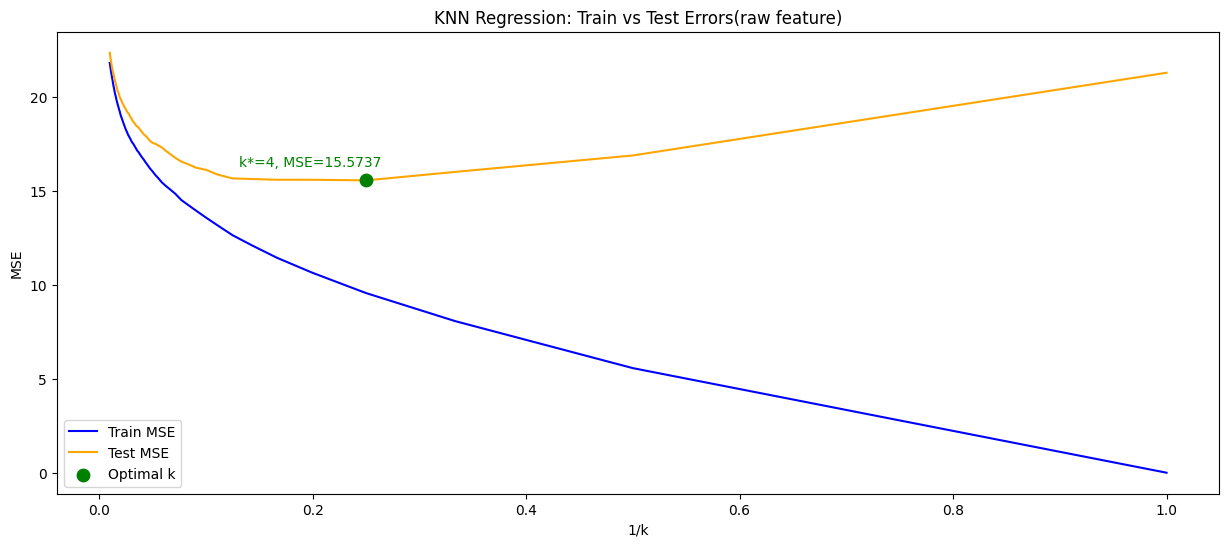

In [485]:
# Plot Train & Test errors vs 1/k for raw feature
plt.figure(figsize=(15, 6))

plt.plot([1/k for k in k_values], train_mse_raw, label="Train MSE", color="blue")
plt.plot([1/k for k in k_values], test_mse_raw, label="Test MSE", color="orange")

plt.scatter(1/optimal_test_k_raw, least_test_mse_raw, color="green", s=80, zorder=5, label="Optimal k")
plt.annotate(f"k*={optimal_test_k_raw}, MSE={least_test_mse_raw:.4f}", 
             (1/optimal_test_k_raw, least_test_mse_raw),
             textcoords="offset points", xytext=(-40,10), ha="center", color="green")


plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression: Train vs Test Errors(raw feature)")
plt.legend()
plt.show()

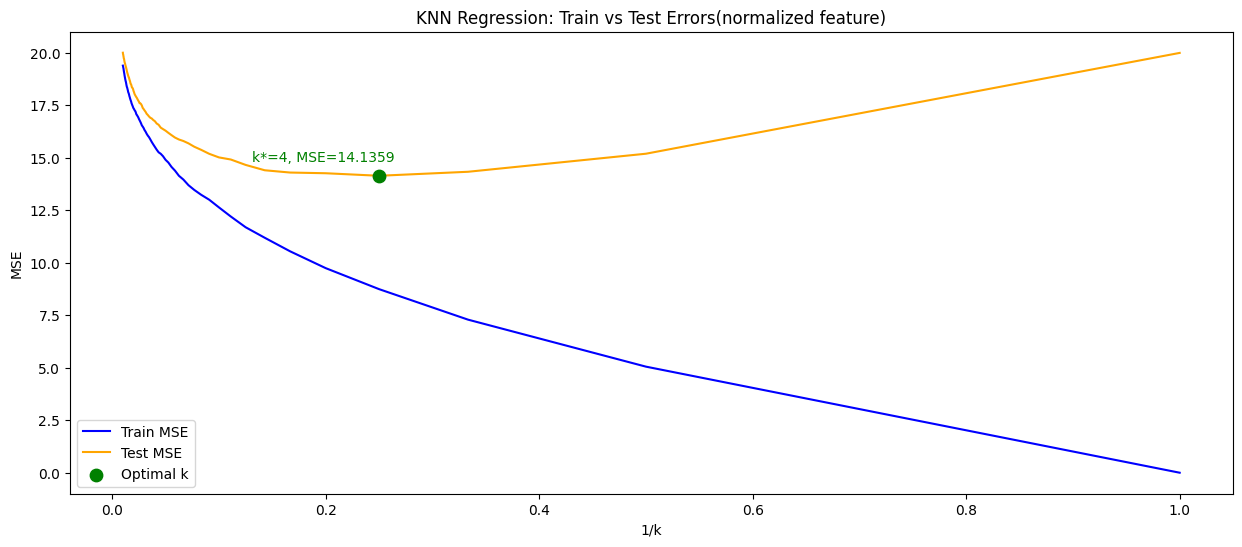

In [486]:
# Plot Train & Test errors vs 1/k for normalized feature
plt.figure(figsize=(15, 6))

plt.plot([1/k for k in k_values], train_mse_norm, label="Train MSE", color="blue")
plt.plot([1/k for k in k_values], test_mse_norm, label="Test MSE", color="orange")

plt.scatter(1/optimal_test_k_norm, least_test_mse_norm, color="green", s=80, zorder=5, label="Optimal k")
plt.annotate(f"k*={optimal_test_k_norm}, MSE={least_test_mse_norm:.4f}", 
             (1/optimal_test_k_norm, least_test_mse_norm),
             textcoords="offset points", xytext=(-40,10), ha="center", color="green")


plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression: Train vs Test Errors(normalized feature)")
plt.legend()
plt.show()

### (j) Compare KNN and Linear

In [487]:
# Summarize the test MSE for each model
mse_summary = {
    "Multiple Linear Regression": mlr_test_mse,
    "Interaction + Polynomial Regression": inter_poly_test_mse,
    "KNN Regression (raw features)": least_test_mse_raw,
    "KNN Regression (normalized features)": least_test_mse_norm
}

mse_df = pd.DataFrame(list(mse_summary.items()), columns=["Model", "Test MSE"])

print(mse_df.round(4))

                                  Model  Test MSE
0            Multiple Linear Regression   20.6321
1   Interaction + Polynomial Regression   18.1503
2         KNN Regression (raw features)   15.5737
3  KNN Regression (normalized features)   14.1359


From the table we can see, among linear regression models, Interaction + Polynomial Regression performs better than Multiple Linear Regression. This reflects the non-linear associations and correlations among variables. If we split them and treat them linearly and independently, the trained model will ignore these relationships and cause higher error rate.

Overall, KNN Regression models perform better than all the linear regression models. Dislike linear regression model assuming a fixed formula of variables, the KNN model uses distance metrics to find neighbours to make prediction. It can treat complex relationship among variables and outliers better. Between KNN Regression models of raw features and normalized features, the one with normalized featured obtained lowest MSE among all the models. It is because normalizing the features ensures all predictors contribute equally to distance calculations, improving KNN performance.

Note that in our case, although KNN models perform better than linear regression models, the test error are relatively close. This indicates that PE still has a strong linear relationship with the predictors. The response is still predictable by linear regression models.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

Flexible statistical learning methods will likely perform <u>**better**</u> than inflexible method.

When n is extremely large, it means there are a large number of data points in the data set, which reduces the variance. The flexible methods will catch the pattern well with lower risk of overfitting.

Meanwhile, with a small number of predictors p, the inflexible methods could be underfitting when the data is not perfectly linear or simple.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

Flexible statistical learning methods will likely perform <u>**worse**</u> than inflexible method.

A dataset with extremely large p and small n will have very high variance, which could easily lead to overfitting in flexible methods. The flexible methods will catch each observations but lose generality.

When it comes to inflexible methods, a simple model will provide a more stable infrastructure to predict the response.

### (c) The relationship between the predictors and response is highly non-linear.

Flexible statistical learning methods will likely perform <u>**better**</u> than inflexible method.

Flexible methods can fit non-linearities better because it doesn't need a formula at the beginning of setup to predict. This allows them to catch complex patterns more accurately, reducing bias.

It is hard for inflexible methods to predict non-linear relationship.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Flexible statistical learning methods will likely perform <u>**worse**</u> than inflexible method.

When the variance of the error terms is extremely high, it means there is a lot of noise in the data. When we apply flexible models to the data, the process of fitting the data closely will be affected by the noise a lot, which will cause model overfitting.

When use inflexible methods, it could spread the influence of noise by using a simple but stable model.

## 3. ISLR: 2.4.7

In [488]:
# Load the data
data = {
    'X1': [0, 2, 0, 0, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 2, 1, 1],
    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']
}

# Convert the data to dataframe and set the index aligned with the observation number
df = pd.DataFrame(data)
df.index += 1
print(df)

   X1  X2  X3      Y
1   0   3   0    Red
2   2   0   0    Red
3   0   1   3    Red
4   0   1   2  Green
5  -1   0   1  Green
6   1   1   1    Red


### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distance between two points is,
$$
d(p, q) = \sqrt{(p_1​−q_1)^2 + (p_2​−q_2)^2 + ... + (p_n​−q_n)^2}​
$$
Given the test point is (0, 0, 0), the euclidean distance can be calculated by,
$$
d=\sqrt{(X_1​−0)^2 + (X_2​−0)^2 + (X_3​−0)^2}​=\sqrt{{X_1}^2 ​+ {X_2}^2 ​+ {X_3}^2​}
$$

In [489]:
test_point = np.array([0, 0, 0])

df['Euclidean_distance'] = np.sqrt((df['X1'] - test_point[0])**2 +
                                   (df['X2'] - test_point[1])**2 +
                                   (df['X3'] - test_point[2])**2)

print("\nEuclidean distances to the test point (0, 0, 0):")
df


Euclidean distances to the test point (0, 0, 0):


,X1,X2,X3,Y,Euclidean_distance
1,0,3,0,Red,3.000000
2,2,0,0,Red,2.000000
3,0,1,3,Red,3.162278
4,0,1,2,Green,2.236068
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051


In [490]:
# Sort the data by euclidean distance by ascending order for the convience of (b) and (c)
df_sorted = df.sort_values(by='Euclidean_distance', ascending=True)
df_sorted

,X1,X2,X3,Y,Euclidean_distance
5,-1,0,1,Green,1.414214
6,1,1,1,Red,1.732051
2,2,0,0,Red,2.000000
4,0,1,2,Green,2.236068
1,0,3,0,Red,3.000000
3,0,1,3,Red,3.162278


### (b) What is our prediction with K = 1? Why?

When K = 1, it means we look at the nearest neighbour of the test point to make the prediction, which is,

- Observation 5: (-1, 0, 1), Green

So we predict the color of the test point is the same as this observation, which is <u>**Green**</u>.

### (c) What is our prediction with K = 3? Why?

When K = 3, we take 3 nearest neighbours of the test point to make the prediction, which are,

- Observation 5: (-1, 0, 1), Green
- Observation 6: (1, 1, 1), Red
- Observation 2: (2, 0, 0), Red

Among these observations, the color Red appears more than Green. Since K-nearest neighbors predicts the class that occurs most frequently among the neighbors, we predict the test point to be <u>**Red**</u>.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the optimal K to be <u>**small**</u> when the Bayes decision boundary is highly non-linear.

KNN with large K considers more neighbours when making prediction, which reduces variance of the data. It takes average of more data so the decision boundary will be more linear.

KNN with small K focuses more on close neighbours. It will capture more complex and non-linear patterns of the data.

So given the decision boundary is highly non-linear, the optimal K is more likely to be small.

### References:

1. https://www.statsmodels.org/stable/index.html
2. https://www.statsmodels.org/stable/regression.html
3. https://www.datacamp.com/tutorial/qq-plot
4. https://stackoverflow.com/questions/59806035/how-to-view-the-interactions-of-all-categorical-predictors-in-an-ols-model-using
5. https://www.statsmodels.org/stable/example_formulas.html
6. https://stats.stackexchange.com/questions/287425/why-do-you-need-to-scale-data-in-knn
7. https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/
8. https://en.wikipedia.org/wiki/Euclidean_distance